# STARWARS_AUTOCALLS — EDA

Objetivo de este notebook: entender las 3 tablas de origen (`rfqs`, `daily_volatility`,
`underlyings_reference`) antes de decidir la estrategia de integración y feature
engineering. Este notebook es solo para **exploración y decisiones** la lógica que
sobreviva (limpieza, integración) se trasladará a `src/autocalls/data/` para que la
reutilicen tanto el script de entrenamiento como la API.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

rfqs = pd.read_csv("../data/raw/rfqs.csv", parse_dates=["requested_date", "start_date", "end_date"])
vol = pd.read_csv("../data/raw/daily_volatility.csv", parse_dates=["date"])
ref = pd.read_csv("../data/raw/underlyings_reference.csv")

print(rfqs.shape, vol.shape, ref.shape)

print(rfqs.shape, vol.shape, ref.shape)

(25000, 17) (44744, 3) (14, 3)
(25000, 17) (44744, 3) (14, 3)


## 1. Data frames
Me interesa conocer como son los datos, como estás estructuradas las tablas, la tipología, si se requerírá alguna modificación.

In [3]:
rfqs.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   rfq_id                  25000 non-null  str           
 1   product_type            25000 non-null  str           
 2   underlyings             25000 non-null  str           
 3   basket_type             25000 non-null  str           
 4   autocall_barrier_pct    25000 non-null  float64       
 5   protection_barrier_pct  25000 non-null  float64       
 6   no_call_period_months   25000 non-null  int64         
 7   observation_frequency   25000 non-null  str           
 8   quoted_implied_vol      25000 non-null  float64       
 9   notional_credits        25000 non-null  int64         
 10  counterparty            25000 non-null  str           
 11  trader_id               25000 non-null  str           
 12  requested_date          25000 non-null  datetime64[us]
 1

In [4]:
rfqs.head()

,rfq_id,product_type,underlyings,basket_type,autocall_barrier_pct,protection_barrier_pct,no_call_period_months,observation_frequency,quoted_implied_vol,notional_credits,counterparty,trader_id,requested_date,executed,start_date,end_date,avg_duration_months
0,RFQ-000000,Kessel Run Snowball,CLNE|DRC,worst_of,1.0000,0.5424,3,Monthly,0.2455,250000,Jabba Asset Management,TRD-015,2022-09-08,False,2022-09-08,2030-01-22,NaN
1,RFQ-000001,Kessel Run Snowball,SITH|WOOK,worst_of,1.0000,0.6258,6,1Y,0.2365,100000,Corellian Capital,TRD-010,2022-06-10,False,2022-06-10,2030-08-09,NaN
2,RFQ-000002,Death Star Phoenix Note,MNDO|NABO,worst_of,1.0152,0.5899,2,1M,0.2011,100000,Nal Hutta Traders,TRD-026,2019-05-27,False,2019-05-27,2028-12-09,NaN
3,RFQ-000003,Kessel Run Snowball,TECH|SITH,worst_of,1.0000,0.5944,4,6M,0.2755,250000,Chandrila Sovereign Fund,TRD-032,2021-09-01,True,2021-09-01,2026-01-30,30.71
4,RFQ-000004,Mandalorian Twin-Win,JEDI,single,1.3149,0.7880,0,3 months,0.1266,100000,Corellian Capital,TRD-034,2023-04-06,False,2023-04-06,2026-07-13,NaN


In [5]:
vol.info()

<class 'pandas.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              44744 non-null  datetime64[us]
 1   underlying        44744 non-null  str           
 2   realized_vol_63d  44744 non-null  float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 1.2 MB


In [6]:
vol.head()

,date,underlying,realized_vol_63d
0,2014-04-01,KYBR,0.194111
1,2014-04-02,KYBR,0.186989
2,2014-04-03,KYBR,0.188895
3,2014-04-04,KYBR,0.187141
4,2014-04-07,KYBR,0.195557


In [7]:
ref.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   underlying           14 non-null     str    
 1   sector               14 non-null     str    
 2   structural_base_vol  14 non-null     float64
dtypes: float64(1), str(2)
memory usage: 841.0 bytes


In [8]:
ref.head()

,underlying,sector,structural_base_vol
0,KYBR,Mineria de materiales estrategicos,0.22
1,CORL,Logistica y transporte,0.28
2,MNDO,Defensa y armamento,0.35
3,HTTX,Comercio y materias primas,0.50
4,TECH,Tecnologia y automatizacion,0.32


## 1. rfqs.csv — tabla principal

Como en el paso previo se han conocido los tipos, es momento de conocer nulos, y cuántas filas tienen target (*executed=True*).

In [9]:
rfqs.isna().sum()

rfq_id                        0
product_type                  0
underlyings                   0
basket_type                   0
autocall_barrier_pct          0
protection_barrier_pct        0
no_call_period_months         0
observation_frequency         0
quoted_implied_vol            0
notional_credits              0
counterparty                  0
trader_id                     0
requested_date                0
executed                      0
start_date                    0
end_date                      0
avg_duration_months       11204
dtype: int64

In [10]:
rfqs['executed'].value_counts(normalize=True)

executed
True     0.55184
False    0.44816
Name: proportion, dtype: float64

**Hallazgo clave**: solo el 55% de las RFQs se ejecutan (`executed=True`), y solo esas
tienen `avg_duration_months` (target). El resto (11.204 filas) son cotizaciones que nunca
se convirtieron en producto — no sirven para entrenar el modelo de duración, pero antes de
descartarlas conviene comprobar si aportan algo (p. ej. como feature de "tasa de ejecución
por contraparte/trader", o simplemente para EDA de qué se cotiza vs qué se ejecuta).

## 2. Categóricas: `product_type`, `basket_type`, `observation_frequency`

In [11]:
rfqs['product_type'].value_counts()

product_type
Holocron Reverse Convertible    4245
Mandalorian Twin-Win            4216
Wretched Hive Digital           4167
Sith Eternal Snowball           4160
Death Star Phoenix Note         4148
Kessel Run Snowball             4064
Name: count, dtype: int64

In [12]:
rfqs['basket_type'].value_counts()

basket_type
worst_of    16539
single       8461
Name: count, dtype: int64

In [13]:
rfqs['observation_frequency'].value_counts()

observation_frequency
1M            6174
3M            5298
6M            3618
2M            1995
1Y            1601
1D             711
Monthly        670
mensual        667
1 month        658
M              651
Quarterly      576
trimestral     570
Q              566
3 months       559
12M            191
Y              175
Annual         164
anual          156
Name: count, dtype: int64

**Hallazgo clave — dato sucio**: `observation_frequency` tiene la misma información
repetida con etiquetas distintas: `1M`, `Monthly`, `mensual`, `1 month`, `M` son todas
"mensual"; `3M`, `Quarterly`, `trimestral`, `Q`, `3 months` son "trimestral"; `12M`, `Y`,
`Annual`, `anual` son "anual". Hay que normalizar esto a una categoría estándar (o, mejor,
a un valor numérico de meses entre observaciones) antes de meterlo en cualquier modelo —
si no, el modelo verá ~18 categorías donde en realidad hay 6 (1D, 1M, 2M, 3M, 6M, 12M).

In [14]:
freq_map_preview = {
    '1M': 1, 'Monthly': 1, 'mensual': 1, '1 month': 1, 'M': 1,
    '2M': 2,
    '3M': 3, 'Quarterly': 3, 'trimestral': 3, 'Q': 3, '3 months': 3,
    '6M': 6,
    '1Y': 12, '12M': 12, 'Y': 12, 'Annual': 12, 'anual': 12,
    '1D': 1/30,
}
rfqs['obs_freq_months'] = rfqs['observation_frequency'].map(freq_map_preview)
rfqs['obs_freq_months'].isna().sum()  # debe ser 0 si el mapeo cubre todos los valores

np.int64(0)

In [15]:
rfqs['obs_freq_months'].value_counts()

obs_freq_months
1.000000     8820
3.000000     7569
6.000000     3618
12.000000    2287
2.000000     1995
0.033333      711
Name: count, dtype: int64

In [16]:
rfqs.head()

,rfq_id,product_type,underlyings,basket_type,autocall_barrier_pct,protection_barrier_pct,no_call_period_months,observation_frequency,quoted_implied_vol,notional_credits,counterparty,trader_id,requested_date,executed,start_date,end_date,avg_duration_months,obs_freq_months
0,RFQ-000000,Kessel Run Snowball,CLNE|DRC,worst_of,1.0000,0.5424,3,Monthly,0.2455,250000,Jabba Asset Management,TRD-015,2022-09-08,False,2022-09-08,2030-01-22,NaN,1.0
1,RFQ-000001,Kessel Run Snowball,SITH|WOOK,worst_of,1.0000,0.6258,6,1Y,0.2365,100000,Corellian Capital,TRD-010,2022-06-10,False,2022-06-10,2030-08-09,NaN,12.0
2,RFQ-000002,Death Star Phoenix Note,MNDO|NABO,worst_of,1.0152,0.5899,2,1M,0.2011,100000,Nal Hutta Traders,TRD-026,2019-05-27,False,2019-05-27,2028-12-09,NaN,1.0
3,RFQ-000003,Kessel Run Snowball,TECH|SITH,worst_of,1.0000,0.5944,4,6M,0.2755,250000,Chandrila Sovereign Fund,TRD-032,2021-09-01,True,2021-09-01,2026-01-30,30.71,6.0
4,RFQ-000004,Mandalorian Twin-Win,JEDI,single,1.3149,0.7880,0,3 months,0.1266,100000,Corellian Capital,TRD-034,2023-04-06,False,2023-04-06,2026-07-13,NaN,3.0


## 3. La cesta de subyacentes: `underlyings`

`underlyings` viene como string separado por `|` (p. ej. `"KYBR|TECH"`). Necesitamos
saber cuántos subyacentes hay por cesta y cómo se relaciona con `basket_type`.

In [17]:
rfqs['n_underlyings'] = rfqs['underlyings'].str.count(r'\|') + 1
pd.crosstab(rfqs['basket_type'], rfqs['n_underlyings'])

n_underlyings,1,2,3
basket_type,,,
single,8461,0,0
worst_of,0,12379,4160


**Hallazgo**: `single` siempre tiene 1 subyacente; `worst_of` tiene 2 o 3. Esto
confirma que hay que "explotar" `underlyings` en filas individuales para poder cruzar con
`daily_volatility` y `underlyings_reference`, y luego volver a agregar a nivel de RFQ
(quedándonos, por ejemplo, con el subyacente de peor comportamiento/mayor volatilidad de
la cesta — el que manda en la lógica `worst_of`).

In [18]:
all_tickers = set()
for u in rfqs['underlyings']:
    all_tickers.update(u.split('|'))
print(sorted(all_tickers), '->', len(all_tickers), 'tickers distintos')
print('Tickers en underlyings_reference:', sorted(ref['underlying'].unique()))
print('Tickers en daily_volatility:', sorted(vol['underlying'].unique()))
print('¿Coinciden los 3 conjuntos?', all_tickers == set(ref['underlying']) == set(vol['underlying']))

['BSKR', 'CLNE', 'CORL', 'DRC', 'HTTX', 'JEDI', 'KYBR', 'MNDO', 'NABO', 'POBK', 'REBL', 'SITH', 'TECH', 'WOOK'] -> 14 tickers distintos
Tickers en underlyings_reference: ['BSKR', 'CLNE', 'CORL', 'DRC', 'HTTX', 'JEDI', 'KYBR', 'MNDO', 'NABO', 'POBK', 'REBL', 'SITH', 'TECH', 'WOOK']
Tickers en daily_volatility: ['BSKR', 'CLNE', 'CORL', 'DRC', 'HTTX', 'JEDI', 'KYBR', 'MNDO', 'NABO', 'POBK', 'REBL', 'SITH', 'TECH', 'WOOK']
¿Coinciden los 3 conjuntos? True


## 4. Fechas: ¿tiene sentido `requested_date` / `start_date` / `end_date`?

El enunciado dice que `start_date`/`end_date` solo existen si `executed=True`. Comprobemos
si eso se cumple en los datos.

In [19]:
print("Nulos en start_date/end_date entre las NO ejecutadas:")
print(rfqs.loc[~rfqs['executed'], ['start_date', 'end_date']].isna().sum())

Nulos en start_date/end_date entre las NO ejecutadas:
start_date    0
end_date      0
dtype: int64


**Hallazgo — discrepancia con el enunciado**: las RFQs no ejecutadas también tienen
`start_date`/`end_date` rellenos (no hay nulos). El enunciado decía que solo estarían
presentes si `executed=True`. Lectura razonable: esas fechas son las *fechas indicativas*
que se cotizaron en el momento de la RFQ (cuándo empezaría y cuándo vencería el producto
si se ejecutase), no fechas reales de un producto vivo. Para el modelo esto no es un
problema en sí — el target solo existe para `executed=True` de todas formas — pero es
importante no asumir "si tiene start_date, se ejecutó".

In [20]:
ex = rfqs[rfqs['executed']].copy()
print("¿requested_date == start_date en las ejecutadas?",
      (ex['requested_date'] == ex['start_date']).mean())
(ex['start_date'] - ex['requested_date']).dt.days.describe()

¿requested_date == start_date en las ejecutadas? 0.16577268773557552


count    13796.000000
mean         2.519208
std          1.708430
min          0.000000
25%          1.000000
50%          3.000000
75%          4.000000
max          5.000000
dtype: float64

Solo en ~17% de los casos coincide `requested_date` con `start_date` — hay un lag
entre que se cotiza y que arranca el producto. Puede ser una feature en sí misma (tiempo
de negociación antes de ejecutar).

## 5. La variable objetivo: `avg_duration_months`

In [21]:
ex['avg_duration_months'].describe()

count    13796.000000
mean        39.782783
std         22.105132
min          0.160000
25%         23.567500
50%         35.380000
75%         51.952500
max        127.710000
Name: avg_duration_months, dtype: float64

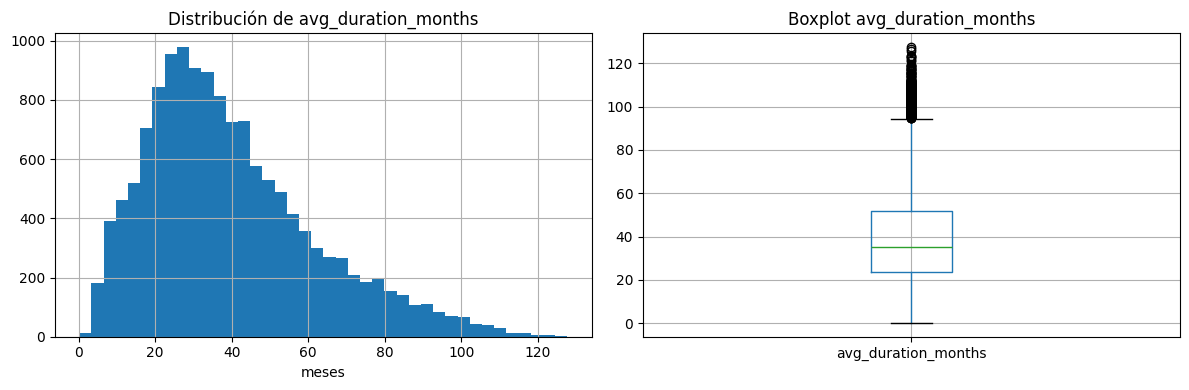

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ex['avg_duration_months'].hist(bins=40, ax=axes[0])
axes[0].set_title('Distribución de avg_duration_months')
axes[0].set_xlabel('meses')

ex.boxplot(column='avg_duration_months', ax=axes[1])
axes[1].set_title('Boxplot avg_duration_months')
plt.tight_layout()
plt.show()

## 6. Duración nominal (vencimiento) vs duración real (target)

`end_date - start_date` nos da el vencimiento nominal del producto. La lógica de negocio
dice que la duración real (`avg_duration_months`) debería ser **siempre menor o igual**
que la nominal, porque el autocall solo puede cancelar el producto *antes* de vencimiento,
nunca después.

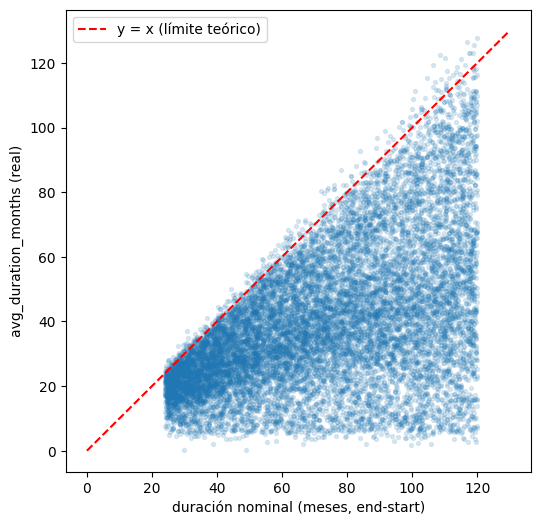

correlación: 0.5256167007072705
Filas donde la duración real supera la nominal (+0.5 meses de margen): 241 de 13796


,rfq_id,nominal_months,avg_duration_months
104,RFQ-000104,45.367937,47.15
161,RFQ-000161,29.697766,30.72
241,RFQ-000241,30.519054,32.52
304,RFQ-000304,45.565046,47.24
314,RFQ-000314,43.528252,44.19
360,RFQ-000360,39.980289,40.96
552,RFQ-000552,38.534823,39.32
592,RFQ-000592,106.307490,112.44
718,RFQ-000718,56.668857,61.20
765,RFQ-000765,117.674113,123.02


In [23]:
ex['nominal_months'] = (ex['end_date'] - ex['start_date']).dt.days / 30.44

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(ex['nominal_months'], ex['avg_duration_months'], alpha=0.15, s=8)
ax.plot([0, 130], [0, 130], color='red', linestyle='--', label='y = x (límite teórico)')
ax.set_xlabel('duración nominal (meses, end-start)')
ax.set_ylabel('avg_duration_months (real)')
ax.legend()
plt.show()

print('correlación:', ex['nominal_months'].corr(ex['avg_duration_months']))
violaciones = (ex['avg_duration_months'] > ex['nominal_months'] + 0.5)
print(f"Filas donde la duración real supera la nominal (+0.5 meses de margen): {violaciones.sum()} de {len(ex)}")
ex.loc[violaciones, ['rfq_id', 'nominal_months', 'avg_duration_months']].head(10)

**Hallazgo — posible problema de calidad de datos**: hay un grupo de filas (a
revisar el número exacto al ejecutar) donde `avg_duration_months` > duración nominal, lo
cual no debería ser posible según la lógica de negocio del producto. Antes de entrenar hay
que decidir: ¿son errores de simulación a tratar como ruido/outliers, o hay algo en el
contrato (p. ej. algún tipo de extensión) que lo justifica? Lo trataremos en la fase de
limpieza, documentando la decisión — no lo vamos a arreglar de forma silenciosa.

## 7. Numéricas de la RFQ: barreras, vol cotizada, nominal, no-call period

In [24]:
num_cols = ['autocall_barrier_pct', 'protection_barrier_pct', 'no_call_period_months',
            'quoted_implied_vol', 'notional_credits']
rfqs[num_cols].describe()

,autocall_barrier_pct,protection_barrier_pct,no_call_period_months,quoted_implied_vol,notional_credits
count,25000.000000,25000.000000,25000.000000,25000.000000,2.500000e+04
mean,1.139004,0.663538,1.480160,0.278661,6.764120e+05
std,0.147257,0.096473,2.016732,0.089055,1.695565e+06
min,0.950000,0.500000,0.000000,0.093600,1.000000e+05
25%,1.000000,0.600000,0.000000,0.217700,1.000000e+05
50%,1.152700,0.622500,0.000000,0.274250,2.500000e+05
75%,1.276100,0.760900,3.000000,0.330500,5.000000e+05
max,1.400000,0.850000,6.000000,0.599700,2.000000e+07


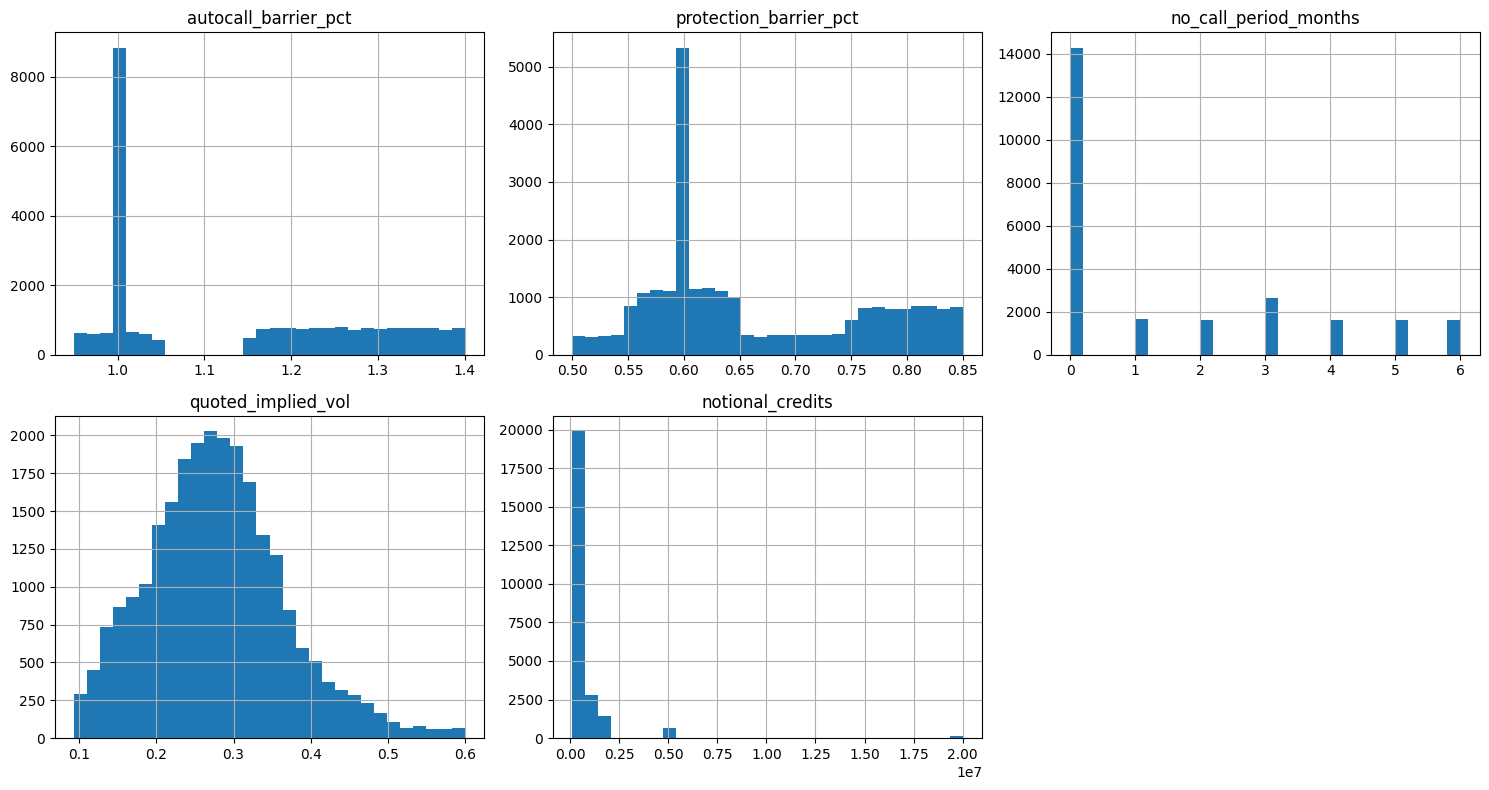

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, num_cols):
    rfqs[col].hist(bins=30, ax=ax)
    ax.set_title(col)
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

Nota: `autocall_barrier_pct` llega a valores por debajo de 1.0 (mínimo 0.95) y por
encima (máximo 1.40) — conviene revisar con el enunciado/negocio si barreras <100% tienen
sentido para este producto o si son un caso especial de algún `product_type` concreto.

In [26]:
pd.crosstab(rfqs['product_type'],
            pd.cut(rfqs['autocall_barrier_pct'], bins=[0.9, 0.99, 1.01, 1.5],
                   labels=['<100%', '=100%', '>100%']))

autocall_barrier_pct,<100%,=100%,>100%
product_type,,,
Death Star Phoenix Note,1659,825,1664
Holocron Reverse Convertible,0,0,4245
Kessel Run Snowball,0,4064,0
Mandalorian Twin-Win,0,0,4216
Sith Eternal Snowball,0,4160,0
Wretched Hive Digital,0,0,4167


## 8. Contrapartes y traders

In [27]:
print('Contrapartes:', rfqs['counterparty'].nunique())
print('Traders:', rfqs['trader_id'].nunique())
rfqs.groupby('counterparty')['executed'].mean().sort_values(ascending=False)

Contrapartes: 8
Traders: 39


counterparty
Kamino Cloning Trust        0.559810
First Order Financial       0.559213
Alderaan Wealth Partners    0.558663
Jabba Asset Management      0.552495
Banco de Coruscant          0.551473
Chandrila Sovereign Fund    0.551040
Corellian Capital           0.545540
Nal Hutta Traders           0.536355
Name: executed, dtype: float64

Tasa de ejecución bastante homogénea entre contrapartes (~54-56%), no parece una
variable con mucho poder discriminante por sí sola para el target de duración (que además
solo se puede calcular sobre las ya ejecutadas).

## 9. `daily_volatility.csv` — panel de mercado

In [28]:
vol.isna().sum()

date                0
underlying          0
realized_vol_63d    0
dtype: int64

In [29]:
print('Rango de fechas:', vol['date'].min(), '->', vol['date'].max())
vol.groupby('underlying')['date'].agg(['min', 'max', 'count'])

Rango de fechas: 2014-04-01 00:00:00 -> 2026-06-30 00:00:00


,min,max,count
underlying,,,
BSKR,2014-04-01,2026-06-30,3196
CLNE,2014-04-01,2026-06-30,3196
CORL,2014-04-01,2026-06-30,3196
DRC,2014-04-01,2026-06-30,3196
HTTX,2014-04-01,2026-06-30,3196
JEDI,2014-04-01,2026-06-30,3196
KYBR,2014-04-01,2026-06-30,3196
MNDO,2014-04-01,2026-06-30,3196
NABO,2014-04-01,2026-06-30,3196


Cobertura completa y homogénea: los 14 tickers tienen datos diarios desde 2014-04-01
hasta 2026-06-30, sin huecos aparentes. Esto cubre de sobra el rango de `requested_date` de
las RFQs (2016-2024), así que podremos sacar la volatilidad realizada vigente en el momento
de cada cotización sin problemas de cobertura.

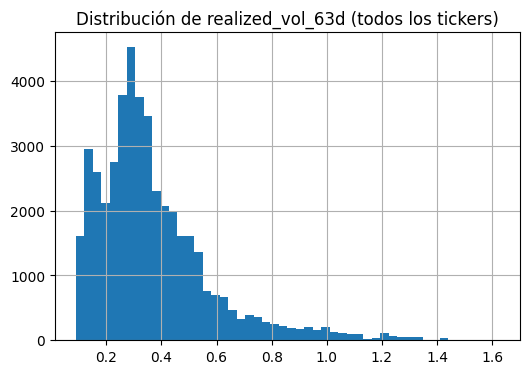

In [30]:
vol['realized_vol_63d'].hist(bins=50, figsize=(6, 4))
plt.title('Distribución de realized_vol_63d (todos los tickers)')
plt.show()

In [31]:
vol.groupby('underlying')['realized_vol_63d'].agg(['mean', 'std', 'min', 'max']).sort_values('mean', ascending=False)

,mean,std,min,max
underlying,,,,
HTTX,0.874216,0.258285,0.394662,1.623879
POBK,0.507089,0.127861,0.318955,0.882680
REBL,0.477894,0.210695,0.144111,0.990827
MNDO,0.429858,0.116416,0.292208,0.823188
TECH,0.391437,0.099285,0.258121,0.698525
DRC,0.381730,0.098755,0.230288,0.638206
BSKR,0.364846,0.094702,0.207635,0.592139
CORL,0.345805,0.085733,0.222109,0.595311
WOOK,0.332874,0.085027,0.205218,0.569540


## 10. `underlyings_reference.csv` — tabla estática

In [32]:
ref

,underlying,sector,structural_base_vol
0,KYBR,Mineria de materiales estrategicos,0.22
1,CORL,Logistica y transporte,0.28
2,MNDO,Defensa y armamento,0.35
3,HTTX,Comercio y materias primas,0.50
4,TECH,Tecnologia y automatizacion,0.32
5,SITH,Energia e infraestructuras,0.26
6,JEDI,Gestion patrimonial,0.14
7,BSKR,Metales y aleaciones,0.30
8,POBK,Ocio y entretenimiento,0.42
9,NABO,Agricultura y biotecnologia,0.11


In [33]:
ref.sort_values('structural_base_vol', ascending=False)

,underlying,sector,structural_base_vol
3,HTTX,Comercio y materias primas,0.50
8,POBK,Ocio y entretenimiento,0.42
2,MNDO,Defensa y armamento,0.35
4,TECH,Tecnologia y automatizacion,0.32
13,DRC,Consumo y distribucion,0.31
7,BSKR,Metales y aleaciones,0.30
1,CORL,Logistica y transporte,0.28
11,WOOK,Manufactura,0.27
5,SITH,Energia e infraestructuras,0.26
0,KYBR,Mineria de materiales estrategicos,0.22


14 sectores distintos (uno por ticker, sin repetidos), así que `sector` en la
práctica identifica casi 1:1 al ticker — como feature categórica puede ser redundante con
el propio ticker salvo que agrupemos sectores afines. `structural_base_vol` sí aporta una
medida de volatilidad de largo plazo, independiente de la fecha, complementaria a la
volatilidad realizada (que varía en el tiempo).

In [34]:
ref['sector'].nunique(), rfqs.shape[0]

(14, 25000)

## 11. Resumen de hallazgos y decisiones pendientes

**Confirmado:**
- Los 3 conjuntos de tickers coinciden exactamente (14 subyacentes) entre `rfqs`, `daily_volatility` y `underlyings_reference`.
- Cobertura temporal del panel de volatilidad cubre de sobra el rango de fechas de las RFQs.
- Solo las RFQs con `executed=True` (13.796 de 25.000) tienen target.

**Data quality a resolver antes de modelar:**
1. `observation_frequency` tiene ~18 valores que en realidad son 6 categorías (normalizar a meses entre observaciones).
2. Un subconjunto de filas tiene `avg_duration_months` > duración nominal (`end_date - start_date`) — decidir si se filtran, se recortan (clip) o se investigan como un régimen de contrato distinto.
3. `autocall_barrier_pct` tiene valores fuera del rango "típico" (<100% y hasta 140%) — confirmar si es coherente con negocio o requiere revisión.

**Para decidir en la fase de integración/features:**
- Cómo agregar la cesta (`worst_of` de 2-3 subyacentes) a nivel de RFQ: ¿volatilidad del subyacente con mayor vol realizada en la fecha de la RFQ? ¿media? ¿la del sector con peor `structural_base_vol`?
- Qué fecha usar para cruzar con `daily_volatility`: `requested_date` (momento de la cotización, evita leakage) parece la elección correcta — nunca usar información posterior a la cotización.
- Si las RFQs no ejecutadas aportan algo (features de contexto/mercado) aunque no tengan target, o se descartan directamente del dataset de entrenamiento.

Siguiente paso: cerrar estas decisiones y pasar la lógica de limpieza + integración a `src/autocalls/data/`.